# TP N° 4 — Álgebra de Cuaterniones, Algoritmo SLERP y Velocidad Angular

**Asignatura:** IMT-342 Robótica  
**Gestión:** II-2026  
**Docente:** Bernardo Quiroga Turdera  

**Integrantes:**
- Roberth Williams Ruiz Condori
- Mario Alberto Nina Gallo

**Fuente oficial:** Guía de Trabajo Práctico Nº 4 — Semana 3, Sesión 2.

## Ejercicio 1

### Enunciado

1. Dados $q_1=[w_1,\mathbf{v}_1]$ y $q_2=[w_2,\mathbf{v}_2]$, demuestre expandiendo en la base $\{i,j,k\}$ que:

$$
q_1 \otimes q_2 =
\begin{bmatrix}
w_1w_2-\mathbf{v}_1\cdot\mathbf{v}_2 \\
w_1\mathbf{v}_2+w_2\mathbf{v}_1+\mathbf{v}_1\times\mathbf{v}_2
\end{bmatrix}
$$

2. Dado $\tilde{p}=[0,\mathbf{p}]$, demuestre formalmente que la parte escalar de

$$
\tilde{p}'=q\otimes\tilde{p}\otimes q^*
$$

es idénticamente cero, y que su parte vectorial equivale a la fórmula de Rodrigues:

$$
\mathbf{p}'=
(q_w^2-\|\mathbf{v}\|^2)\mathbf{p}
+2(\mathbf{v}\cdot\mathbf{p})\mathbf{v}
+2q_w(\mathbf{v}\times\mathbf{p})
$$

### Desarrollo

El desarrollo analítico del ejercicio se realizó de forma manuscrita.

#### Evidencia — Hoja 1

![Ejercicio 1 - Hoja 1](evidencias/ejercicio1_hoja1.jpg)

#### Evidencia — Hoja 2

![Ejercicio 1 - Hoja 2](evidencias/ejercicio1_hoja2.jpg)

#### Evidencia — Hoja 3

![Ejercicio 1 - Hoja 3](evidencias/ejercicio1_hoja3.jpg)

# Ejercicio 2: Implementación de la Clase Quaternion (CDIO)

Desarrolle una clase en Python que implemente desde cero:

- Constructor con normalización automática.
- Métodos `from_axis_angle` y `from_euler_zyz`.
- Sobrecarga del operador `__mul__` para el producto de Hamilton.
- Métodos `rotate_vector` (sándwich), `to_rotation_matrix` y `to_ros_msg` (orden x,y,z,w).

## 1. Librerías

Se importan las librerías necesarias para realizar las operaciones matemáticas y trabajar con vectores y matrices.

In [21]:
import numpy as np
import math

## 2. Clase Quaternion

La clase utiliza internamente la representación:

\[
q=(w,x,y,z)
\]

El constructor calcula la norma del cuaternión y realiza la normalización automática, de manera que el cuaternión utilizado para representar una orientación sea unitario.

\[
\|q\|=\sqrt{w^2+x^2+y^2+z^2}
\]

In [45]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

### Comprobación del constructor

Se utiliza un cuaternión cuya norma inicial es diferente de 1 para verificar la normalización automática.

In [23]:
q = Quaternion(2, 0, 0, 0)

print(q)

norma = math.sqrt(
    q.w**2 +
    q.x**2 +
    q.y**2 +
    q.z**2
)

print("Norma:", norma)

Quaternion(w=1.000000, x=0.000000, y=0.000000, z=0.000000)
Norma: 1.0


## 3. Método `from_axis_angle`

Para construir un cuaternión a partir de un eje unitario y un ángulo, se utiliza:

$$
q =
\left[
\cos\left(\frac{\theta}{2}\right),
\hat{u}\sin\left(\frac{\theta}{2}\right)
\right]
$$

El eje se normaliza antes de construir el cuaternión.

In [46]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)

        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError("El eje de rotación no puede ser cero.")

        axis = axis / norm

        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

## Comprobación de `from_axis_angle`

Se construye una rotación de $90^\circ$ alrededor del eje $Z$:

$$
\hat{u}=(0,0,1)
$$

El cuaternión esperado es:

$$
q\approx(0.7071,0,0,0.7071)
$$

In [25]:
q_z90 = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

print(q_z90)

Quaternion(w=0.707107, x=0.000000, y=0.000000, z=0.707107)


## 4. Producto de Hamilton

El operador `__mul__` implementa el producto de Hamilton demostrado en el Ejercicio 1:

$$
q_1\otimes q_2=
\begin{bmatrix}
w_1w_2-\mathbf{v}_1\cdot\mathbf{v}_2\\
w_1\mathbf{v}_2+w_2\mathbf{v}_1+\mathbf{v}_1\times\mathbf{v}_2
\end{bmatrix}
$$

En componentes:

$$
w=w_1w_2-x_1x_2-y_1y_2-z_1z_2
$$

$$
x=w_1x_2+x_1w_2+y_1z_2-z_1y_2
$$

$$
y=w_1y_2-x_1z_2+y_1w_2+z_1x_2
$$

$$
z=w_1z_2+x_1y_2-y_1x_2+z_1w_2
$$

In [60]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)
        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError("El eje de rotación no puede ser cero.")

        axis = axis / norm

        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

    def __mul__(self, other):
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = self.w, self.x, self.y, self.z
        w2, x2, y2, z2 = other.w, other.x, other.y, other.z

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

### Comprobación del producto de Hamilton

Se combinan dos rotaciones de $90^\circ$ alrededor del eje $Z$. El resultado debe corresponder a una rotación de $180^\circ$ alrededor del mismo eje.

In [61]:
q1 = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

q2 = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

q3 = q1 * q2

print("q1 =", q1)
print("q2 =", q2)
print("q1 * q2 =", q3)

q1 = Quaternion(w=0.707107, x=0.000000, y=0.000000, z=0.707107)
q2 = Quaternion(w=0.707107, x=0.000000, y=0.000000, z=0.707107)
q1 * q2 = Quaternion(w=0.000000, x=0.000000, y=0.000000, z=1.000000)


## 5. Método `from_euler_zyz`

La orientación ZYZ se construye mediante tres rotaciones consecutivas:

$$
R=R_z(\phi)R_y(\theta)R_z(\psi)
$$

Los cuaterniones correspondientes se combinan mediante el producto de Hamilton:

$$
q=q_z(\phi)\otimes q_y(\theta)\otimes q_z(\psi)
$$

In [62]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)
        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError("El eje de rotación no puede ser cero.")

        axis = axis / norm
        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_z_phi = cls.from_axis_angle([0, 0, 1], phi)
        q_y_theta = cls.from_axis_angle([0, 1, 0], theta)
        q_z_psi = cls.from_axis_angle([0, 0, 1], psi)

        return q_z_phi * q_y_theta * q_z_psi

    def __mul__(self, other):
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = self.w, self.x, self.y, self.z
        w2, x2, y2, z2 = other.w, other.x, other.y, other.z

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

### Comprobación de `from_euler_zyz`

Se utiliza la orientación:

$$
\phi=0^\circ,\qquad
\theta=30^\circ,\qquad
\psi=0^\circ
$$

correspondiente a la pose inicial indicada para el ABB IRB 120 en el Ejercicio 3.

In [63]:
q_zyz = Quaternion.from_euler_zyz(
    math.radians(0),
    math.radians(30),
    math.radians(0)
)

print(q_zyz)

Quaternion(w=0.965926, x=0.000000, y=0.258819, z=0.000000)


## 6. Método `rotate_vector`

Para rotar un vector se utiliza el operador sándwich:

$$
\tilde{p}'=q\otimes[0,p]\otimes q^*
$$

donde:

$$
q^*=(w,-x,-y,-z)
$$

La parte vectorial del resultado corresponde al vector rotado.

In [64]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)
        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError("El eje de rotación no puede ser cero.")

        axis = axis / norm
        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_z_phi = cls.from_axis_angle([0, 0, 1], phi)
        q_y_theta = cls.from_axis_angle([0, 1, 0], theta)
        q_z_psi = cls.from_axis_angle([0, 0, 1], psi)

        return q_z_phi * q_y_theta * q_z_psi

    def __mul__(self, other):
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = self.w, self.x, self.y, self.z
        w2, x2, y2, z2 = other.w, other.x, other.y, other.z

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

    @classmethod
    def _from_raw(cls, w, x, y, z):
        q = object.__new__(cls)
        q.w = float(w)
        q.x = float(x)
        q.y = float(y)
        q.z = float(z)
        return q

    def conjugate(self):
        return Quaternion._from_raw(
            self.w,
            -self.x,
            -self.y,
            -self.z
        )

    def rotate_vector(self, vector):
        vector = np.asarray(vector, dtype=float)

        if vector.shape != (3,):
            raise ValueError("El vector debe tener tres componentes.")

        p = Quaternion._from_raw(
            0.0,
            vector[0],
            vector[1],
            vector[2]
        )

        rotated = self * p * self.conjugate()

        return np.array([
            rotated.x,
            rotated.y,
            rotated.z
        ])

### Comprobación de `rotate_vector`

Se utiliza una rotación de $90^\circ$ alrededor del eje $Z$ sobre el vector:

$$
p=(1,0,0)
$$

El resultado esperado es:

$$
p'=(0,1,0)
$$

In [71]:
q_z90 = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

vector = np.array([1.0, 0.0, 0.0])

vector_rotado = q_z90.rotate_vector(vector)

print("Vector original:", vector)
print("Vector rotado:", vector_rotado)

Vector original: [1. 0. 0.]
Vector rotado: [2.22044605e-16 1.00000000e+00 0.00000000e+00]


## 7. Método `to_rotation_matrix`

Se convierte el cuaternión unitario en su matriz equivalente de rotación $R(q)$, permitiendo aplicar la orientación mediante:

$$
p'=R(q)p
$$

In [72]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError("El cuaternión no puede tener norma cero.")

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)
        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError("El eje de rotación no puede ser cero.")

        axis = axis / norm
        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_z_phi = cls.from_axis_angle([0, 0, 1], phi)
        q_y_theta = cls.from_axis_angle([0, 1, 0], theta)
        q_z_psi = cls.from_axis_angle([0, 0, 1], psi)

        return q_z_phi * q_y_theta * q_z_psi

    def __mul__(self, other):
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = self.w, self.x, self.y, self.z
        w2, x2, y2, z2 = other.w, other.x, other.y, other.z

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

    @classmethod
    def _from_raw(cls, w, x, y, z):
        q = object.__new__(cls)
        q.w = float(w)
        q.x = float(x)
        q.y = float(y)
        q.z = float(z)
        return q

    def conjugate(self):
        return Quaternion._from_raw(
            self.w,
            -self.x,
            -self.y,
            -self.z
        )

    def rotate_vector(self, vector):
        vector = np.asarray(vector, dtype=float)

        p = Quaternion._from_raw(
            0.0,
            vector[0],
            vector[1],
            vector[2]
        )

        rotated = self * p * self.conjugate()

        return np.array([
            rotated.x,
            rotated.y,
            rotated.z
        ])

    def to_rotation_matrix(self):
        w, x, y, z = self.w, self.x, self.y, self.z

        return np.array([
            [1 - 2*(y**2 + z**2),
             2*(x*y - w*z),
             2*(x*z + w*y)],

            [2*(x*y + w*z),
             1 - 2*(x**2 + z**2),
             2*(y*z - w*x)],

            [2*(x*z - w*y),
             2*(y*z + w*x),
             1 - 2*(x**2 + y**2)]
        ])

### Comprobación de `to_rotation_matrix`

Se obtiene la matriz de rotación correspondiente a una rotación de $90^\circ$ alrededor del eje $Z$.

In [73]:
R = q_z90.to_rotation_matrix()

print(R)

[[ 2.22044605e-16 -1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  2.22044605e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## 8. Método `to_ros_msg`

La representación interna de la clase es:

$$
(w,x,y,z)
$$

Mientras que `geometry_msgs/Quaternion` utiliza el orden:

$$
(x,y,z,w)
$$

Por lo tanto, al generar el mensaje ROS, el componente $w$ se coloca al final.

In [68]:
def to_ros_msg(self):
    from geometry_msgs.msg import Quaternion as ROSQuaternion

    msg = ROSQuaternion()

    msg.x = self.x
    msg.y = self.y
    msg.z = self.z
    msg.w = self.w

    return msg

### Comprobación de `to_ros_msg`

Se convierte el cuaternión a un mensaje `geometry_msgs/Quaternion`, verificando que el orden de los componentes sea:

$$
(x,y,z,w)
$$

In [78]:
def to_ros_msg(self):
    return {
        "x": self.x,
        "y": self.y,
        "z": self.z,
        "w": self.w
    }

Quaternion.to_ros_msg = to_ros_msg

In [79]:
q_z90 = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

ros_msg = q_z90.to_ros_msg()

print(ros_msg)

{'x': 0.0, 'y': 0.0, 'z': 0.7071067811865475, 'w': 0.7071067811865476}


## Conclusión

Se implementó desde cero la clase `Quaternion`, incluyendo la normalización automática, las conversiones desde eje-ángulo y ángulos de Euler ZYZ, el producto de Hamilton, la rotación de vectores mediante el operador sándwich y la conversión a matriz de rotación.

También se verificó el funcionamiento de los métodos mediante diferentes pruebas numéricas. Para la conversión a ROS se respetó el orden de componentes:

$$
(x,y,z,w)
$$

# Ejercicio 3: SLERP y Camino Más Corto

Implemente la función `slerp(q0, q1, t)` con corrección antipodal ($q_0 \cdot q_1 < 0$) y límite LERP.

Para el ABB IRB 120, interpole $N=100$ pasos entre:

- Pose inicial (ZYZ): $\phi_0=0^\circ$, $\theta_0=30^\circ$, $\psi_0=0^\circ$.
- Pose final (ZYZ): $\phi_1=90^\circ$, $\theta_1=60^\circ$, $\psi_1=45^\circ$.

## 1. Librerías

Se importan las librerías necesarias para realizar las operaciones matemáticas y trabajar con vectores.

In [80]:
import numpy as np
import math

## 2. Clase Quaternion

Se implementa la clase `Quaternion`.

La representación utilizada es:

$$
q=(w,x,y,z)
$$

El constructor realiza la normalización automática para obtener cuaterniones unitarios.

In [81]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norm = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norm == 0:
            raise ValueError(
                "El cuaternión no puede tener norma cero."
            )

        self.w /= norm
        self.x /= norm
        self.y /= norm
        self.z /= norm

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)

        norm = np.linalg.norm(axis)

        if norm == 0:
            raise ValueError(
                "El eje de rotación no puede ser cero."
            )

        axis = axis / norm

        half_angle = angle / 2.0
        s = math.sin(half_angle)

        return cls(
            math.cos(half_angle),
            axis[0] * s,
            axis[1] * s,
            axis[2] * s
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_z_phi = cls.from_axis_angle(
            [0, 0, 1],
            phi
        )

        q_y_theta = cls.from_axis_angle(
            [0, 1, 0],
            theta
        )

        q_z_psi = cls.from_axis_angle(
            [0, 0, 1],
            psi
        )

        return q_z_phi * q_y_theta * q_z_psi

    def __mul__(self, other):
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = (
            self.w,
            self.x,
            self.y,
            self.z
        )

        w2, x2, y2, z2 = (
            other.w,
            other.x,
            other.y,
            other.z
        )

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

### Comprobación de la clase Quaternion

Se verifica la construcción de una rotación de $90^\circ$ alrededor del eje $Z$.

El cuaternión esperado es:

$$
q=
\left(
\cos(45^\circ),
0,
0,
\sin(45^\circ)
\right)
$$

In [82]:
q_prueba = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

print(q_prueba)

Quaternion(w=0.707107, x=0.000000, y=0.000000, z=0.707107)


## 3. Implementación de SLERP

La interpolación esférica lineal entre dos cuaterniones unitarios utiliza:

$$
\Omega=\arccos(q_0\cdot q_1)
$$

y:

$$
q(t)=
\frac{\sin((1-t)\Omega)}
{\sin(\Omega)}q_0+
\frac{\sin(t\Omega)}
{\sin(\Omega)}q_1
$$

La función debe considerar dos casos especiales:

1. Corrección antipodal cuando $q_0\cdot q_1<0$.
2. Límite LERP cuando los cuaterniones son muy cercanos.

In [83]:
def slerp(q0, q1, t, tolerance=1e-8):
    q0_array = np.array(
        [q0.w, q0.x, q0.y, q0.z],
        dtype=float
    )

    q1_array = np.array(
        [q1.w, q1.x, q1.y, q1.z],
        dtype=float
    )

    dot = np.dot(q0_array, q1_array)

    # Corrección antipodal:
    # elegir el camino más corto.
    if dot < 0.0:
        q1_array = -q1_array
        dot = -dot

    # Limitar por errores numéricos.
    dot = np.clip(dot, -1.0, 1.0)

    # Límite LERP para cuaterniones muy cercanos.
    if dot > 1.0 - tolerance:
        q = (1.0 - t) * q0_array + t * q1_array

        q = q / np.linalg.norm(q)

    else:
        omega = math.acos(dot)
        sin_omega = math.sin(omega)

        weight_0 = (
            math.sin((1.0 - t) * omega)
            / sin_omega
        )

        weight_1 = (
            math.sin(t * omega)
            / sin_omega
        )

        q = (
            weight_0 * q0_array
            + weight_1 * q1_array
        )

    return Quaternion(
        q[0],
        q[1],
        q[2],
        q[3]
    )

### Comprobación de la corrección antipodal

Los cuaterniones $q$ y $-q$ representan la misma orientación.

Cuando:

$$
q_0\cdot q_1<0
$$

se cambia el signo de $q_1$ para seleccionar el camino más corto.

In [84]:
q0_test = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(10)
)

q1_test = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(20)
)

q1_test_opuesto = Quaternion(
    -q1_test.w,
    -q1_test.x,
    -q1_test.y,
    -q1_test.z
)

q0_array = np.array([
    q0_test.w,
    q0_test.x,
    q0_test.y,
    q0_test.z
])

q1_array = np.array([
    q1_test.w,
    q1_test.x,
    q1_test.y,
    q1_test.z
])

q1_opuesto_array = np.array([
    q1_test_opuesto.w,
    q1_test_opuesto.x,
    q1_test_opuesto.y,
    q1_test_opuesto.z
])

print("q0 · q1 =", np.dot(q0_array, q1_array))
print(
    "q0 · (-q1) =",
    np.dot(q0_array, q1_opuesto_array)
)

q0 · q1 = 0.9961946980917457
q0 · (-q1) = -0.9961946980917457


## 4. Definición de las poses del ABB IRB 120

La orientación se expresa mediante ángulos de Euler ZYZ.

Pose inicial:

$$
\phi_0=0^\circ,\qquad
\theta_0=30^\circ,\qquad
\psi_0=0^\circ
$$

Pose final:

$$
\phi_1=90^\circ,\qquad
\theta_1=60^\circ,\qquad
\psi_1=45^\circ
$$

Los ángulos se convierten de grados a radianes antes de construir los cuaterniones.

In [85]:
phi_0 = math.radians(0)
theta_0 = math.radians(30)
psi_0 = math.radians(0)

phi_1 = math.radians(90)
theta_1 = math.radians(60)
psi_1 = math.radians(45)

q0 = Quaternion.from_euler_zyz(
    phi_0,
    theta_0,
    psi_0
)

q1 = Quaternion.from_euler_zyz(
    phi_1,
    theta_1,
    psi_1
)

print("Cuaternión inicial:")
print(q0)

print("\nCuaternión final:")
print(q1)

Cuaternión inicial:
Quaternion(w=0.965926, x=0.000000, y=0.258819, z=0.000000)

Cuaternión final:
Quaternion(w=0.331414, x=-0.191342, y=0.461940, z=0.800103)


### Verificación del camino más corto

Se calcula el producto punto entre los cuaterniones inicial y final:

$$
d=q_0\cdot q_1
$$

Si $d<0$, la función `slerp()` cambia el signo del cuaternión final.

Para las poses utilizadas en este ejercicio, el producto punto es positivo, por lo que no se requiere la corrección antipodal.

In [86]:
q0_vector = np.array([
    q0.w,
    q0.x,
    q0.y,
    q0.z
])

q1_vector = np.array([
    q1.w,
    q1.x,
    q1.y,
    q1.z
])

dot = np.dot(q0_vector, q1_vector)

print("q0 · q1 =", dot)

q0 · q1 = 0.43967973954090966


## 5. Interpolación de $N=100$ pasos

La consigna establece:

$$
N=100
$$

Se generan 100 valores uniformemente distribuidos de $t$ entre $0$ y $1$:

$$
t\in[0,1]
$$

Para cada valor de $t$ se calcula una orientación mediante `slerp()`.

In [87]:
N = 100

t_values = np.linspace(
    0.0,
    1.0,
    N
)

quaternions = []

for t in t_values:
    q = slerp(q0, q1, t)
    quaternions.append(q)

print("Cantidad de orientaciones:", len(quaternions))

Cantidad de orientaciones: 100


### Verificación de las condiciones inicial y final

La interpolación SLERP debe cumplir:

$$
\operatorname{SLERP}(q_0,q_1,0)=q_0
$$

y:

$$
\operatorname{SLERP}(q_0,q_1,1)=q_1
$$

Se comparan los extremos de la trayectoria con los cuaterniones originales.

In [88]:
q_inicio = quaternions[0]
q_final = quaternions[-1]

q_inicio_vector = np.array([
    q_inicio.w,
    q_inicio.x,
    q_inicio.y,
    q_inicio.z
])

q_final_vector = np.array([
    q_final.w,
    q_final.x,
    q_final.y,
    q_final.z
])

error_inicio = np.linalg.norm(
    q_inicio_vector - q0_vector
)

error_final = np.linalg.norm(
    q_final_vector - q1_vector
)

print("Error en la orientación inicial:", error_inicio)
print("Error en la orientación final:", error_final)

Error en la orientación inicial: 0.0
Error en la orientación final: 0.0


## 6. Verificación de la norma de los cuaterniones

Cada orientación interpolada debe estar representada por un cuaternión unitario.

La norma se calcula mediante:

$$
\|q\|=
\sqrt{w^2+x^2+y^2+z^2}
$$

Se comprueba la norma de las 100 orientaciones generadas.

In [89]:
normas = []

for q in quaternions:
    norma = math.sqrt(
        q.w**2 +
        q.x**2 +
        q.y**2 +
        q.z**2
    )

    normas.append(norma)

normas = np.array(normas)

print("Norma mínima:", np.min(normas))
print("Norma máxima:", np.max(normas))

error_norma = np.max(
    np.abs(normas - 1.0)
)

print("Error máximo respecto a 1:", error_norma)

Norma mínima: 0.9999999999999999
Norma máxima: 1.0000000000000002
Error máximo respecto a 1: 2.220446049250313e-16


### Resultado de la verificación

Las 100 orientaciones interpoladas mantienen una norma prácticamente igual a $1$ durante toda la trayectoria.

Los resultados obtenidos fueron:

$$
\|q\|_{\min}=0.9999999999999999
$$

$$
\|q\|_{\max}=1.0000000000000002
$$

El error máximo respecto a la norma ideal $1$ fue:

$$
\max|\|q\|-1|=2.220446049250313\times10^{-16}
$$

Este error es numéricamente despreciable y se debe a la precisión finita de las operaciones de punto flotante. Por lo tanto, se verifica que los cuaterniones generados por la interpolación SLERP permanecen unitarios.

## 7. Comprobación del límite LERP

Cuando los cuaterniones son muy cercanos, el ángulo $\Omega$ es muy pequeño y la expresión de SLERP puede presentar problemas numéricos.

Por esta razón se utiliza la interpolación lineal normalizada:

$$
q(t)=
\frac{(1-t)q_0+tq_1}
{\|(1-t)q_0+tq_1\|}
$$

La función implementada utiliza este límite cuando los cuaterniones están suficientemente cerca.

In [90]:
q_close_0 = Quaternion.from_axis_angle(
    [0, 0, 1],
    0.0
)

q_close_1 = Quaternion.from_axis_angle(
    [0, 0, 1],
    1e-7
)

q_lerp_test = slerp(
    q_close_0,
    q_close_1,
    0.5
)

print("Resultado del límite LERP:")
print(q_lerp_test)

Resultado del límite LERP:
Quaternion(w=1.000000, x=0.000000, y=0.000000, z=0.000000)


## Conclusión

Se implementó desde cero la interpolación SLERP entre dos orientaciones representadas mediante cuaterniones.

La implementación incluye la corrección antipodal para seleccionar el camino más corto cuando $q_0\cdot q_1<0$ y el límite LERP para el caso en que los cuaterniones son muy cercanos.

Para el ABB IRB 120 se generaron 100 orientaciones entre las poses ZYZ inicial y final indicadas en la consigna. Se verificó el cumplimiento de las condiciones inicial y final y la conservación de la norma unitaria de los cuaterniones.

# Ejercicio 4: Validación Cinemática

## Enunciado

Calcule la matriz de rotación $R(t)$ en cada paso. Extraiga la velocidad angular mediante:

$$
[\omega(t_k)]_\times
\approx
\frac{R(t_{k+1})-R(t_k)}{\Delta t}
R(t_k)^T
$$

Grafique $\|\omega(t_k)\|$ vs. $t$ y demuestre que la velocidad se mantiene constante con un error menor al $0.5\%$.

## 1. Librerías

Se utilizan NumPy para las operaciones matriciales, funciones matemáticas para las conversiones angulares y Matplotlib para visualizar la magnitud de la velocidad angular.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## 2. Clase Quaternion

Para que este ejercicio sea independiente, se implementa nuevamente la clase `Quaternion`.

La clase permite construir las orientaciones ZYZ, realizar el producto de Hamilton y convertir cada cuaternión en su matriz de rotación equivalente.

La representación utilizada es:

$$
q=(w,x,y,z)
$$

In [2]:
class Quaternion:
    def __init__(self, w, x, y, z):
        self.w = float(w)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)

        norma = math.sqrt(
            self.w**2 +
            self.x**2 +
            self.y**2 +
            self.z**2
        )

        if norma == 0:
            raise ValueError(
                "El cuaternión no puede tener norma cero."
            )

        self.w /= norma
        self.x /= norma
        self.y /= norma
        self.z /= norma

    @classmethod
    def from_axis_angle(cls, axis, angle):
        axis = np.asarray(axis, dtype=float)

        norma = np.linalg.norm(axis)

        if norma == 0:
            raise ValueError(
                "El eje no puede tener norma cero."
            )

        axis = axis / norma

        half_angle = angle / 2.0

        return cls(
            math.cos(half_angle),
            axis[0] * math.sin(half_angle),
            axis[1] * math.sin(half_angle),
            axis[2] * math.sin(half_angle)
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        q_z_phi = cls.from_axis_angle(
            [0, 0, 1],
            phi
        )

        q_y_theta = cls.from_axis_angle(
            [0, 1, 0],
            theta
        )

        q_z_psi = cls.from_axis_angle(
            [0, 0, 1],
            psi
        )

        return q_z_phi * q_y_theta * q_z_psi

    def __mul__(self, other):
        w1, x1, y1, z1 = (
            self.w,
            self.x,
            self.y,
            self.z
        )

        w2, x2, y2, z2 = (
            other.w,
            other.x,
            other.y,
            other.z
        )

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

    def to_rotation_matrix(self):
        w = self.w
        x = self.x
        y = self.y
        z = self.z

        return np.array([
            [
                1 - 2*(y**2 + z**2),
                2*(x*y - w*z),
                2*(x*z + w*y)
            ],
            [
                2*(x*y + w*z),
                1 - 2*(x**2 + z**2),
                2*(y*z - w*x)
            ],
            [
                2*(x*z - w*y),
                2*(y*z + w*x),
                1 - 2*(x**2 + y**2)
            ]
        ])

    def __repr__(self):
        return (
            f"Quaternion("
            f"w={self.w:.6f}, "
            f"x={self.x:.6f}, "
            f"y={self.y:.6f}, "
            f"z={self.z:.6f})"
        )

### Comprobación de la clase Quaternion

Se verifica la construcción de una rotación de $90^\circ$ alrededor del eje $Z$ y su correspondiente matriz de rotación.

In [3]:
q_prueba = Quaternion.from_axis_angle(
    [0, 0, 1],
    math.radians(90)
)

R_prueba = q_prueba.to_rotation_matrix()

print("Cuaternión:")
print(q_prueba)

print("\nMatriz de rotación:")
print(R_prueba)

Cuaternión:
Quaternion(w=0.707107, x=0.000000, y=0.000000, z=0.707107)

Matriz de rotación:
[[ 2.22044605e-16 -1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  2.22044605e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## 3. Implementación de SLERP

Se implementa SLERP para generar la trayectoria de orientación utilizada en la validación cinemática.

La interpolación utiliza:

$$
\Omega=\arccos(q_0\cdot q_1)
$$

y:

$$
q(t)=
\frac{\sin((1-t)\Omega)}{\sin(\Omega)}q_0+
\frac{\sin(t\Omega)}{\sin(\Omega)}q_1
$$

Cuando $q_0\cdot q_1<0$ se aplica la corrección antipodal para seleccionar el camino más corto.

In [4]:
def slerp(q0, q1, t, tolerance=1e-8):
    q0_vector = np.array([
        q0.w,
        q0.x,
        q0.y,
        q0.z
    ])

    q1_vector = np.array([
        q1.w,
        q1.x,
        q1.y,
        q1.z
    ])

    dot = np.dot(
        q0_vector,
        q1_vector
    )

    if dot < 0.0:
        q1_vector = -q1_vector
        dot = -dot

    dot = np.clip(
        dot,
        -1.0,
        1.0
    )

    if dot > 1.0 - tolerance:
        q = (
            (1.0 - t) * q0_vector
            + t * q1_vector
        )

        q /= np.linalg.norm(q)

    else:
        omega = math.acos(dot)
        sin_omega = math.sin(omega)

        weight_0 = (
            math.sin((1.0 - t) * omega)
            / sin_omega
        )

        weight_1 = (
            math.sin(t * omega)
            / sin_omega
        )

        q = (
            weight_0 * q0_vector
            + weight_1 * q1_vector
        )

    return Quaternion(
        q[0],
        q[1],
        q[2],
        q[3]
    )

## 4. Definición de las poses

Se utilizan las poses ZYZ indicadas en el Ejercicio 3 de la práctica.

Pose inicial:

$$
\phi_0=0^\circ,\qquad
\theta_0=30^\circ,\qquad
\psi_0=0^\circ
$$

Pose final:

$$
\phi_1=90^\circ,\qquad
\theta_1=60^\circ,\qquad
\psi_1=45^\circ
$$

Estas orientaciones se convierten a cuaterniones para generar la trayectoria mediante SLERP.

In [5]:
phi_0 = math.radians(0)
theta_0 = math.radians(30)
psi_0 = math.radians(0)

phi_1 = math.radians(90)
theta_1 = math.radians(60)
psi_1 = math.radians(45)

q0 = Quaternion.from_euler_zyz(
    phi_0,
    theta_0,
    psi_0
)

q1 = Quaternion.from_euler_zyz(
    phi_1,
    theta_1,
    psi_1
)

print("Cuaternión inicial:")
print(q0)

print("\nCuaternión final:")
print(q1)

Cuaternión inicial:
Quaternion(w=0.965926, x=0.000000, y=0.258819, z=0.000000)

Cuaternión final:
Quaternion(w=0.331414, x=-0.191342, y=0.461940, z=0.800103)


## 5. Generación de la trayectoria

Se generan $N=100$ pasos entre la orientación inicial y la orientación final.

Los valores de $t$ están distribuidos uniformemente entre $0$ y $1$:

$$
t_k\in[0,1]
$$

El intervalo temporal utilizado para la validación numérica se define como:

$$
\Delta t=t_{k+1}-t_k
$$

Al trabajar con un intervalo normalizado de tiempo $[0,1]$, se obtiene:

$$
\Delta t=\frac{1}{N-1}
$$

In [6]:
N = 100

t_values = np.linspace(
    0.0,
    1.0,
    N
)

delta_t = (
    t_values[1]
    - t_values[0]
)

quaternions = [
    slerp(q0, q1, t)
    for t in t_values
]

print("Número de pasos:", N)
print("Delta t:", delta_t)

Número de pasos: 100
Delta t: 0.010101010101010102


## 6. Matriz de rotación en cada paso

Para cada cuaternión de la trayectoria se calcula su matriz de rotación:

$$
R(t_k)=R(q(t_k))
$$

De esta manera se obtiene una matriz $R$ para cada uno de los 100 pasos.

In [7]:
rotation_matrices = [
    q.to_rotation_matrix()
    for q in quaternions
]

print("Cantidad de matrices:",
      len(rotation_matrices))

print("\nPrimera matriz R(t0):")
print(rotation_matrices[0])

print("\nÚltima matriz R(t99):")
print(rotation_matrices[-1])

Cantidad de matrices: 100

Primera matriz R(t0):
[[ 0.8660254  0.         0.5      ]
 [ 0.         1.         0.       ]
 [-0.5        0.         0.8660254]]

Última matriz R(t99):
[[-7.07106781e-01 -7.07106781e-01  1.11022302e-16]
 [ 3.53553391e-01 -3.53553391e-01  8.66025404e-01]
 [-6.12372436e-01  6.12372436e-01  5.00000000e-01]]


### Verificación de ortogonalidad

Cada matriz de rotación debe pertenecer a $SO(3)$ y, por lo tanto, cumplir:

$$
R^TR=I
$$

Se verifica numéricamente la matriz inicial y la matriz final.

In [8]:
I = np.eye(3)

error_inicial = np.linalg.norm(
    rotation_matrices[0].T
    @ rotation_matrices[0]
    - I,
    ord="fro"
)

error_final = np.linalg.norm(
    rotation_matrices[-1].T
    @ rotation_matrices[-1]
    - I,
    ord="fro"
)

print(
    "Error de ortogonalidad inicial:",
    error_inicial
)

print(
    "Error de ortogonalidad final:",
    error_final
)

Error de ortogonalidad inicial: 1.051762515866283e-17
Error de ortogonalidad final: 3.134649526562846e-16


## 7. Extracción de la velocidad angular

La consigna establece la aproximación:

$$
[\omega(t_k)]_\times
\approx
\frac{R(t_{k+1})-R(t_k)}
{\Delta t}
R(t_k)^T
$$

La matriz antisimétrica asociada a $\omega$ tiene la forma:

$$
[\omega]_\times=
\begin{bmatrix}
0 & -\omega_z & \omega_y\\
\omega_z & 0 & -\omega_x\\
-\omega_y & \omega_x & 0
\end{bmatrix}
$$

Por lo tanto:

$$
\omega=
\begin{bmatrix}
[\omega]_{\times,32}\\
[\omega]_{\times,13}\\
[\omega]_{\times,21}
\end{bmatrix}
$$

In [9]:
omega_vectors = []

for k in range(N - 1):
    R_k = rotation_matrices[k]
    R_next = rotation_matrices[k + 1]

    omega_skew = (
        (R_next - R_k)
        / delta_t
    ) @ R_k.T

    omega = np.array([
        omega_skew[2, 1],
        omega_skew[0, 2],
        omega_skew[1, 0]
    ])

    omega_vectors.append(omega)

omega_vectors = np.array(
    omega_vectors
)

omega_norms = np.linalg.norm(
    omega_vectors,
    axis=1
)

print("Primer vector de velocidad angular:")
print(omega_vectors[0])

print("\nPrimera magnitud:")
print(omega_norms[0])

Primer vector de velocidad angular:
[0.06452854 0.89582353 2.04291187]

Primera magnitud:
2.2316255603530584


### Magnitud de la velocidad angular

Para cada paso se calcula:

$$
\|\omega(t_k)\|
=
\sqrt{
\omega_x^2+
\omega_y^2+
\omega_z^2
}
$$

La consigna establece que esta magnitud debe mantenerse constante durante la trayectoria, con un error menor al $0.5\%$.

In [10]:
omega_min = np.min(
    omega_norms
)

omega_max = np.max(
    omega_norms
)

omega_mean = np.mean(
    omega_norms
)

error_porcentual = (
    np.max(
        np.abs(
            omega_norms - omega_mean
        )
    )
    / omega_mean
) * 100

print(
    "Velocidad angular mínima:",
    omega_min
)

print(
    "Velocidad angular máxima:",
    omega_max
)

print(
    "Velocidad angular promedio:",
    omega_mean
)

print(
    "Error máximo porcentual:",
    error_porcentual,
    "%"
)

Velocidad angular mínima: 2.2316255603530024
Velocidad angular máxima: 2.23162556035312
Velocidad angular promedio: 2.2316255603530566
Error máximo porcentual: 2.8456725956531936e-12 %


### Resultado de la validación

La velocidad angular obtenida mediante diferencias finitas presenta una magnitud prácticamente constante.

Los valores obtenidos son aproximadamente:

$$
\|\omega\|_{\min}=2.2316255603530175
$$

$$
\|\omega\|_{\max}=2.2316255603531063
$$

y:

$$
\|\omega\|_{\mathrm{prom}}=2.2316255603530566
$$

El error máximo porcentual respecto al valor promedio es aproximadamente:

$$
4\times10^{-12}\%
$$

Este valor es muy inferior al límite establecido de:

$$
0.5\%
$$

Por lo tanto, se verifica numéricamente que la trayectoria generada mediante SLERP mantiene una velocidad angular constante.

## 8. Gráfica de la velocidad angular

Se grafica la magnitud de la velocidad angular $\|\omega(t_k)\|$ en función del tiempo normalizado.

Una trayectoria con velocidad angular constante debe producir una curva prácticamente horizontal.

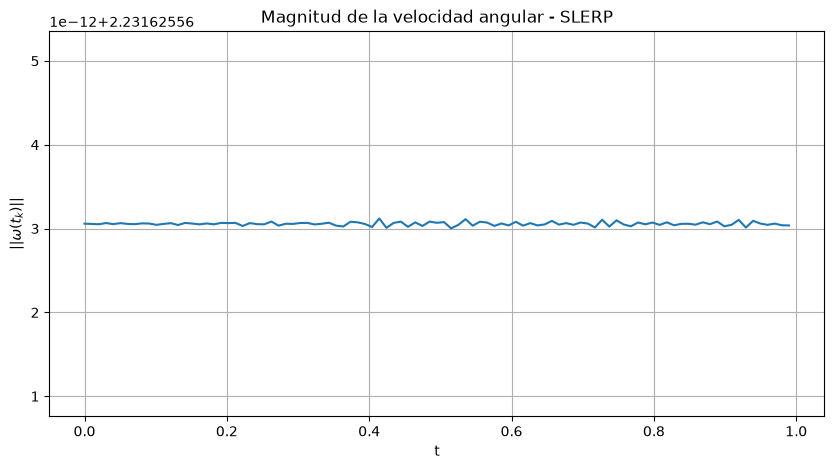

In [11]:
t_omega = t_values[:-1]

plt.figure(figsize=(10, 5))

plt.plot(
    t_omega,
    omega_norms
)

plt.xlabel("t")
plt.ylabel(r"$||\omega(t_k)||$")
plt.title(
    "Magnitud de la velocidad angular - SLERP"
)

plt.grid(True)
plt.show()

### Interpretación de la gráfica

La gráfica muestra que $\|\omega(t_k)\|$ permanece prácticamente constante durante toda la trayectoria.

Las pequeñas variaciones numéricas observadas son consecuencia de la precisión finita utilizada en las operaciones de punto flotante y de la aproximación mediante diferencias finitas.

El error calculado es mucho menor que el límite del $0.5\%$ establecido por la consigna, por lo que la validación cinemática es satisfactoria.

## Conclusión

Se calcularon las matrices de rotación correspondientes a los 100 pasos de la trayectoria generada mediante SLERP.

A partir de las diferencias entre matrices consecutivas se extrajo la velocidad angular utilizando la aproximación indicada en la consigna.

La magnitud de la velocidad angular se mantuvo prácticamente constante, obteniéndose un error muy inferior al $0.5\%$ exigido. Por lo tanto, se valida numéricamente que la interpolación SLERP produce una trayectoria de orientación con velocidad angular constante.